In [4]:
!pip install google-play-scraper pandas

import os
import pandas as pd
from google_play_scraper import Sort, reviews

# Ensuring data directory exists
os.makedirs('data', exist_ok=True)

print("Scraping Zomato reviews...")
zomato_reviews, _ = reviews(
    'com.application.zomato',
    lang='en',
    country='in',
    sort=Sort.NEWEST,
    count=500
)

df_zomato = pd.DataFrame(zomato_reviews)
df_zomato[['userName', 'score', 'at', 'content']].to_csv('data/raw_zomato_reviews.csv', index=False)
print("✓ Zomato data saved!")

print("Scraping Swiggy reviews...")
swiggy_reviews, _ = reviews(
    'in.swiggy.android',
    lang='en',
    country='in',
    sort=Sort.NEWEST,
    count=500
)

df_swiggy = pd.DataFrame(swiggy_reviews)
df_swiggy[['userName', 'score', 'at', 'content']].to_csv('data/raw_swiggy_reviews.csv', index=False)
print("✓ Swiggy data saved!")

Scraping Zomato reviews...
✓ Zomato data saved!
Scraping Swiggy reviews...
✓ Swiggy data saved!


In [5]:
import pandas as pd

# 1. Load the raw data you just scraped
df_zomato = pd.read_csv('data/raw_zomato_reviews.csv')
df_swiggy = pd.read_csv('data/raw_swiggy_reviews.csv')

# 2. Filter for 1, 2, and 3-star reviews only
df_zomato_neg = df_zomato[df_zomato['score'].isin([1, 2, 3])].copy()
df_swiggy_neg = df_swiggy[df_swiggy['score'].isin([1, 2, 3])].copy()

# 3. Define the tagging logic
def categorize_review(text):
    text = str(text).lower()
    
    # Primary Issue Category
    if any(word in text for word in ['missing', 'wrong', 'quantity', 'item', 'incomplete', 'instead']):
        category = 'Order Accuracy'
    elif any(word in text for word in ['refund', 'coupon', 'support', 'chat', 'customer care', 'money', 'return', 'fake', 'scam', 'cheating']):
        category = 'Refund / Support Friction'
    elif any(word in text for word in ['late', 'delay', 'time', 'slow', 'wait']):
        category = 'Delivery Speed'
    elif any(word in text for word in ['cold', 'stale', 'taste', 'quality', 'spilled', 'packaging', 'hygiene', 'smell', 'bad food']):
        category = 'Food Quality'
    elif any(word in text for word in ['glitch', 'crash', 'payment', 'ui', 'update', 'bug', 'location', 'app is']):
        category = 'App Bug / UI'
    elif 'delivered' in text and any(word in text for word in ['not receive', "didn't receive", 'never got']):
        category = 'Delivery Fraud'
    else:
        category = 'Other / Generic'
        
    # Support Contacted
    if any(word in text for word in ['support', 'chat', 'call', 'ticket', 'customer care', 'agent', 'executive', 'bot', 'complaint', 'raised']):
        support = 'Yes'
    elif any(word in text for word in ['could not contact', 'no support', 'no number']):
        support = 'No'
    else:
        support = 'Unclear'
        
    # Outcome
    if any(word in text for word in ['refunded', 'got my money back']):
        outcome = 'Refund Approved'
    elif any(word in text for word in ['coupon', 'credits', 'wallet', 'money in app']):
        outcome = 'Coupon Given'
    elif any(word in text for word in ['denied', 'refused', 'no action', 'unable to take further action', 'no help']):
        outcome = 'Refund Denied'
    elif any(word in text for word in ['no agent', 'bot loop', 'automated reply', 'only bot']):
        outcome = 'No Agent Reachable'
    else:
        outcome = 'N/A'
        
    return pd.Series([category, support, outcome])

# 4. Apply the logic to create the 3 new columns
df_zomato_neg[['Primary Issue Category', 'Support Contacted', 'Outcome']] = df_zomato_neg['content'].apply(categorize_review)
df_swiggy_neg[['Primary Issue Category', 'Support Contacted', 'Outcome']] = df_swiggy_neg['content'].apply(categorize_review)

# 5. Save the final tagged datasets
df_zomato_neg.to_csv('data/tagged_zomato_reviews_final.csv', index=False)
df_swiggy_neg.to_csv('data/tagged_swiggy_reviews_final.csv', index=False)

print("Data successfully transformed and tagged files saved!")

Data successfully transformed and tagged files saved!


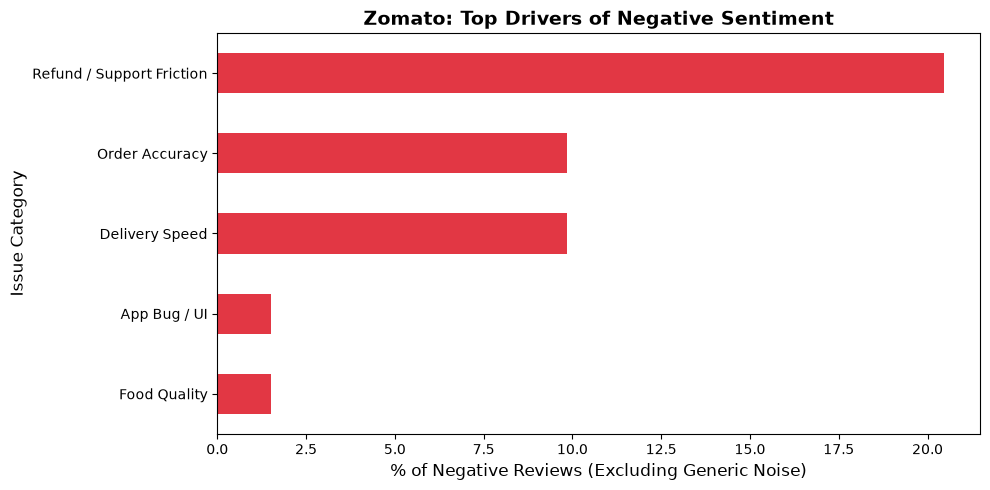

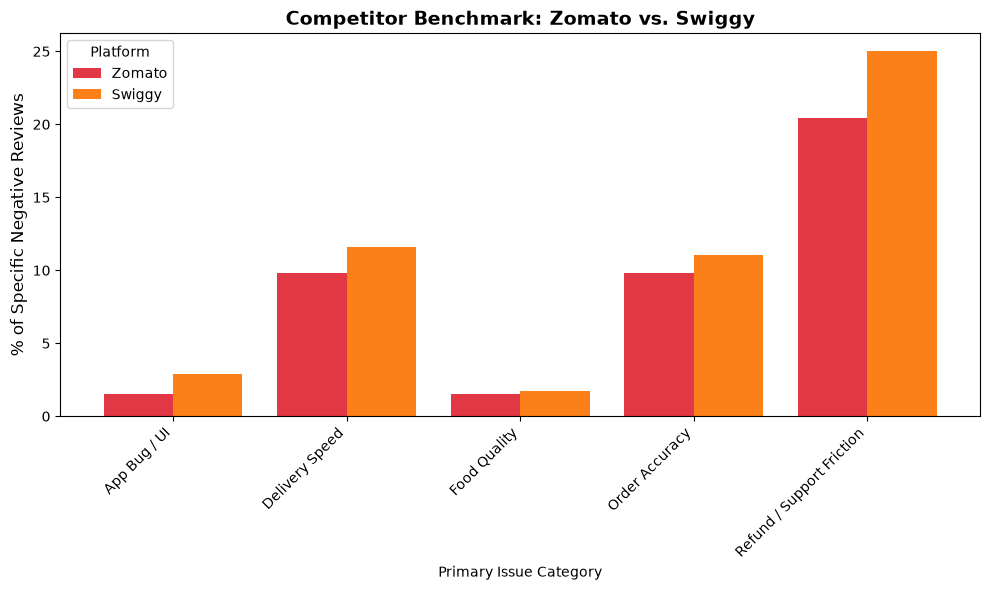

Charts saved successfully in the 'images' folder!


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Create a folder to save images for your README
os.makedirs('images', exist_ok=True)

# 2. Load the tagged datasets from the data folder
df_zomato = pd.read_csv('data/tagged_zomato_reviews_final.csv')
df_swiggy = pd.read_csv('data/tagged_swiggy_reviews_final.csv')

# --- Chart 1: Zomato Issue Breakdown ---
z_counts = df_zomato['Primary Issue Category'].value_counts(normalize=True).drop('Other / Generic') * 100

plt.figure(figsize=(10, 5))
z_counts.sort_values().plot(kind='barh', color='#E23744') # Zomato Red
plt.title('Zomato: Top Drivers of Negative Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('% of Negative Reviews (Excluding Generic Noise)', fontsize=12)
plt.ylabel('Issue Category', fontsize=12)
plt.tight_layout()
plt.savefig('images/zomato_issues.png', dpi=300)
plt.show()

# --- Chart 2: Competitor Benchmark ---
s_counts = df_swiggy['Primary Issue Category'].value_counts(normalize=True).drop('Other / Generic') * 100

# Combine data for comparison
compare_df = pd.DataFrame({
    'Zomato': z_counts,
    'Swiggy': s_counts
}).fillna(0)

# Plotting the benchmark
ax = compare_df.plot(kind='bar', figsize=(10, 6), color=['#E23744', '#FC8019'], width=0.8) # Zomato Red & Swiggy Orange
plt.title('Competitor Benchmark: Zomato vs. Swiggy', fontsize=14, fontweight='bold')
plt.ylabel('% of Specific Negative Reviews', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Platform')
plt.tight_layout()
plt.savefig('images/competitor_benchmark.png', dpi=300)
plt.show()

print("Charts saved successfully in the 'images' folder!")